In [71]:
import xarray as xr
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import scipy.stats as stats
from scipy.stats import weibull_min, linregress, norm
from scipy.special import gamma

In [72]:
DATA_DIR ='era5_out/'

ds_oper = xr.open_mfdataset(
    DATA_DIR + "era5_sl_*_oper.nc",
    combine="by_coords",
    engine="netcdf4"
)

ds_wave = xr.open_mfdataset(
    DATA_DIR + "era5_sl_*_wave.nc",
    combine="by_coords",
    engine="netcdf4"
)

ds = xr.merge([ds_oper, ds_wave])

/tmp/ipykernel_683855/702446443.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_683855/702446443.py:15: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_683855/702446443.py:15: FutureWarning: In a future version of xarray the default value fo

Buoy Positions

M1 : 53.1266°N 11.2000°W	 

M2 : 53.4800°N 05.4250°W	

M3 : 51.2166°N 10.5500°W

M4 : 55.0000°N 10.0000°W	

M5 : 51.6900°N 06.7040°W	

M6 : 53.0605°N 15.9300°W

In [73]:
# subset the years of interest
# ds = ds.sel(valid_time=slice("1974-01-01", "1979-12-31"))

In [84]:
with open(os.path.join("config.json"), "r") as f:
    config = json.load(f)
    
buoy_locations = config['buoys']

First buoy: M1 at (53.127°N, 11.200°W)


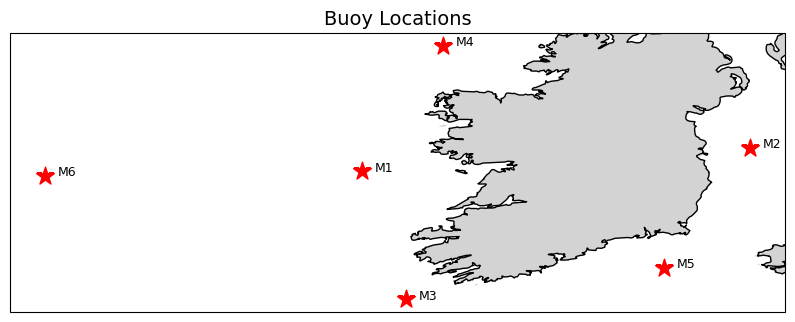

In [75]:
buoy_names = list(buoy_locations.keys())
buoy_lats = [buoy_locations[name]["latitude"] for name in buoy_names]
buoy_lons = [buoy_locations[name]["longitude"] for name in buoy_names]

def format_lat(lat):
    hemi = "N" if lat >= 0 else "S"
    return f"{abs(lat):.3f}°{hemi}"

def format_lon(lon):
    hemi = "E" if lon >= 0 else "W"
    return f"{abs(lon):.3f}°{hemi}"

print(
    f"First buoy: {buoy_names[0]} at "
    f"({format_lat(buoy_lats[0])}, {format_lon(buoy_lons[0])})"
)

fig = plt.figure(figsize=(10, 8), dpi=100, facecolor="white", edgecolor="black")
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.COASTLINE)
ax.scatter(
    buoy_lons,
    buoy_lats,
    color="red",
    marker="*",
    s=180,
    transform=ccrs.PlateCarree(),
)

# Annotate the buoys.
for name, lat, lon in zip(buoy_names, buoy_lats, buoy_lons):
    ax.text(lon + 0.19, lat + 0.0, name, transform=ccrs.PlateCarree(), fontsize=9)

ax.set_title("Buoy Locations", fontsize=14)
plt.show()

In [76]:
location_wise_data = {}

for buoy in buoy_locations:
    buoy_name, buoy_lat, buoy_lon = buoy, buoy_locations[buoy]['latitude'], buoy_locations[buoy]['longitude']

    ds_point = ds.sel(latitude=buoy_lat, longitude=buoy_lon, method='nearest')

    w10 = np.sqrt(ds_point["u10"]**2 + ds_point["v10"]**2)
    w100 = np.sqrt(ds_point["u100"]**2 + ds_point["v100"]**2)
    Hs, Tp, time = ds_point["swh"].values, ds_point["pp1d"].values, ds_point["valid_time"].values

    df = pd.DataFrame(
        {
            "time": time,
            "w10": w10,
            "w100": w100,
            "Hs": Hs,
            "Tp": Tp,
        }
    ).set_index("time")

    # All-sea-states approach (Johannesen): use every observation, not just storm peaks
    n_years = (df.index[-1] - df.index[0]).days / 365.25
    n_obs_per_year = len(df) / n_years
    beta = stats.norm.ppf(1 - 1 / (100 * n_obs_per_year))

    location_wise_data[buoy_name] = {
        "df": df,
        "beta": beta,
        "hs_peaks": df["Hs"].values,
        "tp_peaks": df["Tp"].values,
        "u10_peaks": df["w10"].values,
    }


In [77]:
# fig = plt.figure(figsize=(18, 10))
# colors=['blue', 'orange', 'green', 'red', 'purple', 'brown']
# i = 0
# for buoy_name, data in location_wise_data.items():
#     df = data["df"]
#     i += 1
#     ax = fig.add_subplot(2, 3, i, projection='3d')
#     ax.scatter(df["w10"], df["Hs"], df["Tp"], marker='o', alpha=0.005, color=colors[i-1])
#     ax.set_xlabel("w10 (m/s)")
#     ax.set_ylabel("Hs (m)")
#     ax.set_zlabel("Tp (s)")
#     ax.set_title(f"{buoy_name}: w10, Hs, Tp (ERA5)")

# plt.tight_layout()
# plt.show()

Fitting distributions

In [85]:
location_wise_data

{'M1': {'df':                            w10       w100        Hs        Tp
  time                                                         
  1950-01-01 00:00:00   9.036389  10.367843  2.027975  7.085793
  1950-01-01 01:00:00   8.901368  10.158443  1.917541  7.035500
  1950-01-01 02:00:00   8.893449  10.145606  1.831463  6.988136
  1950-01-01 03:00:00   8.539211   9.666479  1.750991  6.941261
  1950-01-01 04:00:00   9.217091  10.425894  1.703750  6.889503
  ...                        ...        ...       ...       ...
  2025-12-31 19:00:00  14.703668  18.020378  3.681417  8.389015
  2025-12-31 20:00:00  14.996935  18.467335  3.790456  8.482765
  2025-12-31 21:00:00  16.266478  20.076748  3.962450  8.552589
  2025-12-31 22:00:00  16.475937  20.212227  4.092724  8.746437
  2025-12-31 23:00:00  15.624244  18.816376  4.107593  8.996925
  
  [666216 rows x 4 columns],
  'beta': np.float64(4.726746304373306),
  'hs_peaks': array([2.027975 , 1.9175406, 1.8314629, ..., 3.96245  , 4.092724 ,
  

In [86]:
# Weibull and contour helper functions
def _weibull_mom_init(data):
    """Method-of-moments initial guess for Weibull shape and scale (loc=0)."""
    mu = np.mean(data)
    cv = np.std(data) / mu
    k0 = max(0.5, (1 / cv) ** 1.086)
    s0 = mu / gamma(1 + 1 / k0)
    return k0, s0

def fit_hs_weibull(hs_peaks, floc=0.0, show_plot=True):
    k0, s0 = _weibull_mom_init(hs_peaks[hs_peaks > floc] - floc)
    hs_shape, hs_loc, hs_scale = weibull_min.fit(hs_peaks, k0, floc=floc, scale=s0)

    print("Weibull parameters for Hs:")
    print(f"  shape (k):      {hs_shape:.4f}")
    print(f"  location:       {hs_loc:.4f}")
    print(f"  scale (lambda): {hs_scale:.4f}")
    print(f"  mean from fit:  {hs_loc + hs_scale * gamma(1 + 1 / hs_shape):.4f} m")

    if show_plot:
        x = np.linspace(floc, max(np.max(hs_peaks), floc + 8), 200)
        pdf_fitted = weibull_min.pdf(x, hs_shape, loc=hs_loc, scale=hs_scale)
        plt.figure(figsize=(8, 5))
        plt.hist(hs_peaks, bins=40, density=True, alpha=0.7, color="#4A6FA5", label="All sea states (observed)")
        plt.plot(x, pdf_fitted, color="red", linewidth=2, label="Weibull fit")
        plt.xlabel("Hs (m)")
        plt.ylabel("Density")
        plt.title("Hs - Weibull Fit (all sea states)")
        plt.legend()
        plt.show()

    return hs_shape, hs_loc, hs_scale

def fit_tp_weibull(
    hs_peaks, tp_peaks, hs_min=0.5, hs_max=12.0,
    bin_width=1.0, min_bin_count=10, show_plot=True,
    use_constant_std=True,
):
    hs_bins = np.arange(hs_min, hs_max + bin_width, bin_width)
    bin_centers, tp_means, tp_stds = [], [], []

    for i in range(len(hs_bins) - 1):
        mask = (hs_peaks >= hs_bins[i]) & (hs_peaks < hs_bins[i + 1])
        if mask.sum() > min_bin_count:
            bin_centers.append((hs_bins[i] + hs_bins[i + 1]) / 2)
            tp_means.append(np.mean(tp_peaks[mask]))
            tp_stds.append(np.std(tp_peaks[mask]))

    bin_centers = np.array(bin_centers)
    tp_means = np.array(tp_means)
    tp_stds = np.array(tp_stds)

    tp_b, tp_a, r, p, _ = linregress(bin_centers, tp_means)
    tp_std = float(np.mean(tp_stds)) if use_constant_std else tp_stds

    print("Conditional Tp model: mean Tp = a + b * Hs")
    print(f"  intercept (a): {tp_a:.4f}")
    print(f"  slope (b):     {tp_b:.4f}")
    print(f"  R^2:           {r**2:.4f}")
    print(f"  p-value:       {p:.4f}")
    print(f"  std(Tp):       {float(np.mean(tp_stds)):.4f} s (mean across Hs bins)")

    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].scatter(hs_peaks, tp_peaks, alpha=0.3, s=10, color="#4A6FA5")
        axes[0].errorbar(bin_centers, tp_means, yerr=tp_stds, fmt="ro", capsize=5, label="Bin mean +- std")
        hs_line = np.linspace(hs_min, hs_max, 100)
        axes[0].plot(hs_line, tp_a + tp_b * hs_line, "r-", linewidth=2, label=f"Mean Tp fit (R^2={r**2:.2f})")
        axes[0].set_xlabel("Hs (m)")
        axes[0].set_ylabel("Tp (s)")
        axes[0].set_title("Tp vs Hs - All sea states")
        axes[0].legend()
        axes[1].plot(bin_centers, tp_stds, "go-", linewidth=2)
        axes[1].set_xlabel("Hs (m)")
        axes[1].set_ylabel("Std of Tp (s)")
        axes[1].set_title("Spread of Tp within each Hs bin")
        axes[1].grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return tp_a, tp_b, tp_std, r**2, p

# def fit_u10_weibull(hs_peaks, u10_peaks, floc=0.0, show_plot=True):
#     k0, s0 = _weibull_mom_init(u10_peaks[u10_peaks > floc] - floc)
#     u10_shape, u10_loc, u10_scale = weibull_min.fit(u10_peaks, k0, floc=floc, scale=s0)

#     print("Weibull parameters for U10:")
#     print(f"  shape (k):      {u10_shape:.4f}")
#     print(f"  location:       {u10_loc:.4f}")
#     print(f"  scale (lambda): {u10_scale:.4f}")
#     print(f"  mean from fit:  {weibull_min.mean(u10_shape, loc=u10_loc, scale=u10_scale):.4f} m/s")
#     print(f"  std from fit:   {weibull_min.std(u10_shape, loc=u10_loc, scale=u10_scale):.4f} m/s")

#     if show_plot:
#         x = np.linspace(floc, max(np.max(u10_peaks), floc + 12), 200)
#         pdf_fitted = weibull_min.pdf(x, u10_shape, loc=u10_loc, scale=u10_scale)
#         plt.figure(figsize=(8, 5))
#         plt.hist(u10_peaks, bins=40, density=True, alpha=0.7, color="#4A6FA5", label="All sea states (observed)")
#         plt.plot(x, pdf_fitted, color="red", linewidth=2, label="Weibull fit")
#         plt.xlabel("U10 (m/s)")
#         plt.ylabel("Density")
#         plt.title("U10 - Weibull Fit (all sea states)")
#         plt.legend()
#         plt.show()

#     return u10_shape, u10_loc, u10_scale

def fit_wind_weibull(w10_all, show_plot=True, buoy_name=""):
    """
    Fit marginal 2-parameter Weibull to all wind speed observations.
    Mirrors Johannessen eq (4): f_Uw(uw) with scale alpha_W, shape beta_W.
    loc fixed at 0 — Johannessen uses no location shift.
    """
    shape, loc, scale = weibull_min.fit(w10_all, floc=0.0)

    print(f"Marginal Weibull for wind speed (Johannessen eq 4):")
    print(f"  alpha_W (scale): {scale:.4f}")
    print(f"  beta_W  (shape): {shape:.4f}")
    print(f"  mean from fit:   {scale * gamma(1 + 1/shape):.4f} m/s")

    if show_plot:
        x = np.linspace(0, np.max(w10_all) * 1.1, 300)
        pdf = weibull_min.pdf(x, shape, loc=0, scale=scale)
        plt.figure(figsize=(8, 5))
        plt.hist(w10_all, bins=60, density=True,
                 alpha=0.7, color="#4A6FA5", label="Observed (all hours)")
        plt.plot(x, pdf, color="red", linewidth=2, label="Weibull fit")
        plt.xlabel("U10 (m/s)")
        plt.ylabel("Density")
        plt.title(f"Marginal Wind Speed Distribution — {buoy_name}")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return shape, scale   # (beta_W, alpha_W) in Johannessen notation

def fit_hs_given_wind(w10_all, hs_all, n_bins=12, show_plot=True, buoy_name=""):
    """
    Fit conditional Weibull for Hs given wind speed.
    Johannessen eq (5): alpha_Hs = a1 + a2*w^a3,  beta_Hs = b1 + b2*w
    
    Fit a1,a2,a3 and b1,b2 from ERA5 data by:
    1. Bin observations by wind speed
    2. Fit Weibull to Hs in each wind bin -> get alpha(w) and beta(w)
    3. Fit the parametric curves to those bin estimates
    """
    w_bins = np.percentile(w10_all, np.linspace(5, 95, n_bins + 1))
    w_bins = np.unique(w_bins)

    bin_centers, alphas, betas = [], [], []

    for i in range(len(w_bins) - 1):
        mask = (w10_all >= w_bins[i]) & (w10_all < w_bins[i+1])
        hs_bin = hs_all[mask]
        if len(hs_bin) < 50:
            continue
        try:
            sh, loc_, sc = weibull_min.fit(hs_bin, floc=0.0)
            if 0.3 < sh < 8 and 0.1 < sc < 20:
                bin_centers.append((w_bins[i] + w_bins[i+1]) / 2)
                alphas.append(sc)
                betas.append(sh)
        except Exception:
            pass

    bin_centers = np.array(bin_centers)
    alphas = np.array(alphas)
    betas  = np.array(betas)

    # Fit alpha_Hs = a1 + a2 * w^a3 (Johannessen form)
    def alpha_func(w, a1, a2, a3):
        return a1 + a2 * w**a3

    # Fit beta_Hs = b1 + b2 * w (linear, Johannessen form)
    def beta_func(w, b1, b2):
        return b1 + b2 * w

    try:
        popt_alpha, _ = curve_fit(alpha_func, bin_centers, alphas,
                                   p0=[1.8, 0.1, 1.3], maxfev=5000)
        a1, a2, a3 = popt_alpha
    except Exception:
        a1, a2, a3 = 1.8, 0.1, 1.322   # fall back to Johannessen values
        print("  WARNING: alpha fit failed, using Johannessen defaults")

    try:
        popt_beta, _ = curve_fit(beta_func, bin_centers, betas,
                                  p0=[2.0, 0.135], maxfev=5000)
        b1, b2 = popt_beta
    except Exception:
        b1, b2 = 2.0, 0.135
        print("  WARNING: beta fit failed, using Johannessen defaults")

    print(f"Conditional Hs|Wind model (Johannessen eq 5):")
    print(f"  alpha_Hs = {a1:.4f} + {a2:.4f} * w^{a3:.4f}")
    print(f"  beta_Hs  = {b1:.4f} + {b2:.4f} * w")
    print(f"  Johannessen reference: alpha = 1.8 + 0.100*w^1.322")
    print(f"  Johannessen reference: beta  = 2.0 + 0.135*w")

    if show_plot:
        w_line = np.linspace(bin_centers.min(), bin_centers.max(), 100)
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        axes[0].scatter(bin_centers, alphas, color="#4A6FA5",
                        label="Bin estimates", zorder=5)
        axes[0].plot(w_line, alpha_func(w_line, a1, a2, a3),
                     'r-', linewidth=2, label="Fitted curve")
        axes[0].plot(w_line, 1.8 + 0.1*w_line**1.322,
                     'k--', linewidth=1.5, alpha=0.6, label="Johannessen")
        axes[0].set_xlabel("Wind speed (m/s)")
        axes[0].set_ylabel("alpha_Hs (scale)")
        axes[0].set_title(f"Hs Scale Parameter vs Wind — {buoy_name}")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].scatter(bin_centers, betas, color="#4A6FA5",
                        label="Bin estimates", zorder=5)
        axes[1].plot(w_line, beta_func(w_line, b1, b2),
                     'r-', linewidth=2, label="Fitted curve")
        axes[1].plot(w_line, 2.0 + 0.135*w_line,
                     'k--', linewidth=1.5, alpha=0.6, label="Johannessen")
        axes[1].set_xlabel("Wind speed (m/s)")
        axes[1].set_ylabel("beta_Hs (shape)")
        axes[1].set_title(f"Hs Shape Parameter vs Wind — {buoy_name}")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return a1, a2, a3, b1, b2

from scipy.optimize import minimize

def fit_tp_given_hs_wind(w10_all, hs_all, tp_all,
                          n_w_bins=6, n_h_bins=5,
                          show_plot=True, buoy_name=""):
    """
    Fit conditional lognormal for Tp given Hs and wind speed.
    Mirrors Johannessen eq (6-8).
    
    Johannessen functional form for conditional mean:
        mu_Tp(hs, uw) = (c1 + c2*hs^c3) * [1 - c4*(uw - mu_w(hs)) / mu_w(hs)]
    where mu_w(hs) = d1 + d2*hs^d3  (wind speed at which Tp is unaffected)
    
    We fit simplified version: mu_Tp = (c1 + c2*hs^c3) with wind correction.
    sigma_lnTp = (e1 + e2*exp(e3*hs)) * mu_Tp  (Johannessen form)
    """
    # Step 1: bin by (wind, Hs) and compute mean/std of Tp in each bin
    w_edges = np.percentile(w10_all, np.linspace(5, 95, n_w_bins + 1))
    h_edges = np.percentile(hs_all,  np.linspace(5, 95, n_h_bins + 1))

    records = []
    for i in range(len(w_edges) - 1):
        for j in range(len(h_edges) - 1):
            mask = ((w10_all >= w_edges[i]) & (w10_all < w_edges[i+1]) &
                    (hs_all  >= h_edges[j]) & (hs_all  < h_edges[j+1]))
            tp_bin = tp_all[mask]
            if len(tp_bin) < 30:
                continue
            w_c = (w_edges[i] + w_edges[i+1]) / 2
            h_c = (h_edges[j] + h_edges[j+1]) / 2
            mu  = np.mean(tp_bin)
            std = np.std(tp_bin)
            records.append((w_c, h_c, mu, std))

    records = np.array(records)
    w_rec, h_rec, mu_rec, std_rec = records[:,0], records[:,1], records[:,2], records[:,3]

    # Step 2: fit Johannessen functional form for mu_Tp
    # mu_Tp(hs, uw) = (c1 + c2*hs^c3) * (1 - c4*(uw - (d1 + d2*hs^d3)) / (d1 + d2*hs^d3))
    def mu_tp_func(X, c1, c2, c3, c4, d1, d2, d3):
        uw, hs = X
        base    = c1 + c2 * hs**c3
        mu_w_hs = d1 + d2 * hs**d3
        correction = 1 - c4 * (uw - mu_w_hs) / mu_w_hs
        return base * np.clip(correction, 0.5, 2.0)

    try:
        popt, _ = curve_fit(
            mu_tp_func, (w_rec, h_rec), mu_rec,
            p0=[4.883, 2.68, 0.529, 0.19, 1.764, 3.426, 0.78],
            maxfev=10000, bounds=(
                [1, 0, 0.1, 0, 0.1, 0.1, 0.1],
                [10, 10, 2,  1, 10,  10,  2]
            )
        )
        c1, c2, c3, c4, d1, d2, d3 = popt
    except Exception:
        c1, c2, c3, c4 = 4.883, 2.68, 0.529, 0.19
        d1, d2, d3     = 1.764, 3.426, 0.78
        print("  WARNING: mu_Tp fit failed, using Johannessen defaults")

    # Step 3: fit sigma_lnTp = (e1 + e2*exp(e3*hs)) * mu_Tp
    mu_pred = mu_tp_func((w_rec, h_rec), c1, c2, c3, c4, d1, d2, d3)
    vTp_rec = std_rec / mu_pred

    def sigma_func(hs, e1, e2, e3):
        return e1 + e2 * np.exp(e3 * hs)

    try:
        popt_s, _ = curve_fit(sigma_func, h_rec, vTp_rec,
                               p0=[-1.7e-3, 0.259, -0.113], maxfev=5000)
        e1, e2, e3 = popt_s
    except Exception:
        e1, e2, e3 = -1.7e-3, 0.259, -0.113
        print("  WARNING: sigma_Tp fit failed, using Johannessen defaults")

    print(f"Conditional Tp|Hs,Wind model (Johannessen eq 6-8):")
    print(f"  mu_Tp  = ({c1:.4f} + {c2:.4f}*hs^{c3:.4f}) * (1 - {c4:.4f}*(uw-mu_w)/mu_w)")
    print(f"  mu_w(hs) = {d1:.4f} + {d2:.4f}*hs^{d3:.4f}")
    print(f"  sigma_vTp = {e1:.6f} + {e2:.4f}*exp({e3:.4f}*hs)")
    print(f"  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19")
    print(f"  Johannessen: d1=1.764, d2=3.426, d3=0.78")
    print(f"  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113")

    if show_plot:
        mu_fitted = mu_tp_func((w_rec, h_rec), c1, c2, c3, c4, d1, d2, d3)
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        axes[0].scatter(mu_rec, mu_fitted, alpha=0.7, color="#4A6FA5")
        axes[0].plot([mu_rec.min(), mu_rec.max()],
                     [mu_rec.min(), mu_rec.max()], 'r--')
        axes[0].set_xlabel("Observed mean Tp (s)")
        axes[0].set_ylabel("Fitted mean Tp (s)")
        axes[0].set_title(f"mu_Tp fit quality — {buoy_name}")
        axes[0].grid(alpha=0.3)

        hs_line = np.linspace(h_rec.min(), h_rec.max(), 100)
        axes[1].scatter(h_rec, vTp_rec, color="#4A6FA5", alpha=0.7,
                        label="Bin estimates")
        axes[1].plot(hs_line, sigma_func(hs_line, e1, e2, e3),
                     'r-', linewidth=2, label="Fitted")
        axes[1].plot(hs_line, sigma_func(hs_line, -1.7e-3, 0.259, -0.113),
                     'k--', linewidth=1.5, alpha=0.6, label="Johannessen")
        axes[1].set_xlabel("Hs (m)")
        axes[1].set_ylabel("CoV of Tp (sigma/mu)")
        axes[1].set_title(f"Tp variability vs Hs — {buoy_name}")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return c1, c2, c3, c4, d1, d2, d3, e1, e2, e3

def generate_environmental_contour(
    beta, hs_params, tp_params, u10_params, n=100, clip_eps=1e-6
):
    hs_shape, hs_loc, hs_scale = hs_params
    tp_a, tp_b, tp_std = tp_params
    u10_shape, u10_loc, u10_scale = u10_params

    phi = np.linspace(0, np.pi, n)
    theta = np.linspace(0, 2 * np.pi, n)
    PHI, THETA = np.meshgrid(phi, theta)

    u1 = beta * np.sin(PHI) * np.cos(THETA)
    u2 = beta * np.sin(PHI) * np.sin(THETA)
    u3 = beta * np.cos(PHI)

    p1 = np.clip(norm.cdf(u1), clip_eps, 1 - clip_eps)
    p2 = np.clip(norm.cdf(u2), clip_eps, 1 - clip_eps)
    p3 = np.clip(norm.cdf(u3), clip_eps, 1 - clip_eps)

    Hs_contour = weibull_min.ppf(p1, hs_shape, loc=hs_loc, scale=hs_scale)
    tp_mean_contour = tp_a + tp_b * Hs_contour
    Tp_contour = norm.ppf(p2, loc=tp_mean_contour, scale=float(tp_std))
    U10_contour = weibull_min.ppf(p3, u10_shape, loc=u10_loc, scale=u10_scale)

    return {
        "PHI": PHI, "THETA": THETA,
        "u1": u1, "u2": u2, "u3": u3,
        "Hs_contour": Hs_contour,
        "Tp_contour": Tp_contour,
        "U10_contour": U10_contour,
    }


def make_transform_functions(w_shape, w_scale,
                              a1, a2, a3, b1, b2,
                              c1, c2, c3, c4, d1, d2, d3,
                              e1, e2, e3):
    """
    Build Rosenblatt transformation functions from fitted parameters.
    Ordering: Wind (u1) -> Hs|Wind (u2) -> Tp|Hs,Wind (u3)
    Mirrors reproduce_johannesen notebook exactly.
    """

    # ── Wind marginal ────────────────────────────────────────────────
    def F_W(w):
        return 1 - np.exp(-(w / w_scale)**w_shape)

    def F_W_inv(p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return w_scale * (-np.log(1 - p))**(1 / w_shape)

    # ── Hs conditional on wind ───────────────────────────────────────
    def alpha_Hs(w):
        return a1 + a2 * w**a3

    def beta_Hs(w):
        return b1 + b2 * w

    def F_Hs_given_W(h, w):
        return 1 - np.exp(-(h / alpha_Hs(w))**beta_Hs(w))

    def F_Hs_given_W_inv(p, w):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return alpha_Hs(w) * (-np.log(1 - p))**(1 / beta_Hs(w))

    # ── Tp conditional on Hs and wind ───────────────────────────────
    def mu_Tp(hs, uw):
        base    = c1 + c2 * hs**c3
        mu_w_hs = d1 + d2 * hs**d3
        corr    = 1 - c4 * (uw - mu_w_hs) / mu_w_hs
        return base * np.clip(corr, 0.5, 2.0)

    def sigma_lnTp(hs, uw):
        mu  = mu_Tp(hs, uw)
        vTp = (e1 + e2 * np.exp(e3 * hs))
        vTp = np.clip(vTp, 0.01, 0.5)
        return np.sqrt(np.log(1 + vTp**2))

    def mu_lnTp(hs, uw):
        mu  = mu_Tp(hs, uw)
        vTp = (e1 + e2 * np.exp(e3 * hs))
        vTp = np.clip(vTp, 0.01, 0.5)
        return np.log(mu / np.sqrt(1 + vTp**2))

    def F_Tp_given_Hs_W_inv(p, hs, uw):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return np.exp(mu_lnTp(hs, uw) + sigma_lnTp(hs, uw) * norm.ppf(p))

    # ── U-space to physical space ────────────────────────────────────
    def u1_to_W(u1):
        p = np.clip(norm.cdf(u1), 1e-10, 1 - 1e-10)
        return F_W_inv(p)

    def u2_to_Hs(u2, w):
        p = np.clip(norm.cdf(u2), 1e-10, 1 - 1e-10)
        return F_Hs_given_W_inv(p, w)

    def u3_to_Tp(u3, h, w):
        p = np.clip(norm.cdf(u3), 1e-10, 1 - 1e-10)
        return F_Tp_given_Hs_W_inv(p, h, w)

    return u1_to_W, u2_to_Hs, u3_to_Tp

def generate_contour_johannessen(beta, u1_to_W, u2_to_Hs, u3_to_Tp,
                                  n_theta=50, n_phi=100):
    """
    Generate 3D environmental contour using Johannessen ordering.
    Mirrors reproduce_johannesen Cell 3 exactly.
    Ordering: W (u1) -> Hs|W (u2) -> Tp|Hs,W (u3)
    """
    theta_vals = np.linspace(0.01, np.pi - 0.01, n_theta)
    phi_vals   = np.linspace(0, 2 * np.pi, n_phi)

    W_contour  = np.full((n_theta, n_phi), np.nan)
    Hs_contour = np.full((n_theta, n_phi), np.nan)
    Tp_contour = np.full((n_theta, n_phi), np.nan)

    for i, theta in enumerate(theta_vals):
        for j, phi in enumerate(phi_vals):
            u1 = beta * np.cos(theta)
            u2 = beta * np.sin(theta) * np.cos(phi)
            u3 = beta * np.sin(theta) * np.sin(phi)

            try:
                w = u1_to_W(u1)
                h = u2_to_Hs(u2, w)
                t = u3_to_Tp(u3, h, w)

                # Physical bounds
                if not (0 < w < 50):  continue
                if not (0 < h < 30):  continue
                if not (1 < t < 30):  continue

                W_contour[i, j]  = w
                Hs_contour[i, j] = h
                Tp_contour[i, j] = t

            except Exception:
                pass

    valid = ~np.isnan(W_contour)
    print(f"Contour summary:")
    print(f"  Max W  (10m, 1h):    {np.nanmax(W_contour):.2f} m/s")
    print(f"  Max W  (hub, 10min): {np.nanmax(W_contour) * 1.10 * (150/10)**0.11:.2f} m/s")
    print(f"  Max Hs:              {np.nanmax(Hs_contour):.2f} m")
    print(f"  Max Tp:              {np.nanmax(Tp_contour):.2f} s")
    print(f"  Valid points:        {valid.sum()} / {valid.size}")

    return W_contour, Hs_contour, Tp_contour


def plot_contour_projections(Hs_contour, Tp_contour, U10_contour, title):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].scatter(Hs_contour.flatten(), Tp_contour.flatten(), s=1, alpha=0.3, color="#4A6FA5")
    axes[0].set_xlabel("Hs (m)")
    axes[0].set_ylabel("Tp (s)")
    axes[0].set_title("Contour: Hs vs Tp")
    axes[0].grid(alpha=0.3)
    axes[1].scatter(Hs_contour.flatten(), U10_contour.flatten(), s=1, alpha=0.3, color="#4A6FA5")
    axes[1].set_xlabel("Hs (m)")
    axes[1].set_ylabel("U10 (m/s)")
    axes[1].set_title("Contour: Hs vs U10")
    axes[1].grid(alpha=0.3)
    axes[2].scatter(Tp_contour.flatten(), U10_contour.flatten(), s=1, alpha=0.3, color="#4A6FA5")
    axes[2].set_xlabel("Tp (s)")
    axes[2].set_ylabel("U10 (m/s)")
    axes[2].set_title("Contour: Tp vs U10")
    axes[2].grid(alpha=0.3)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()



BUOY: M1

Beta (100-year, 8766 obs/yr): 4.7267

--- Wind marginal ---
Marginal Weibull for wind speed (Johannessen eq 4):
  alpha_W (scale): 9.3879
  beta_W  (shape): 2.2831
  mean from fit:   8.3162 m/s


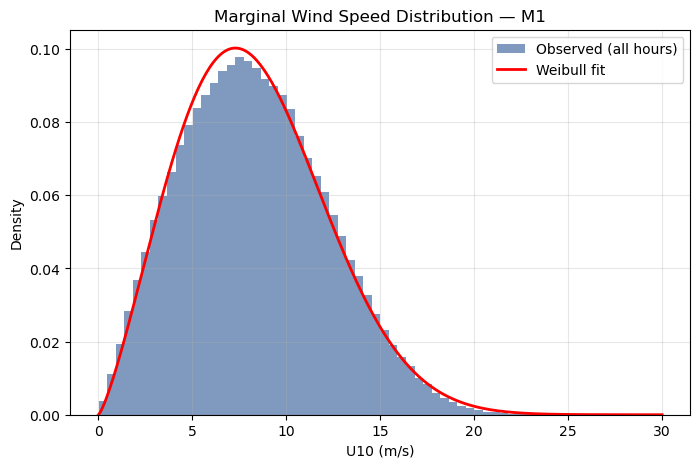


--- Hs conditional on wind ---
Conditional Hs|Wind model (Johannessen eq 5):
  alpha_Hs = 1.8000 + 0.1000 * w^1.3220
  beta_Hs  = 2.0000 + 0.1350 * w
  Johannessen reference: alpha = 1.8 + 0.100*w^1.322
  Johannessen reference: beta  = 2.0 + 0.135*w


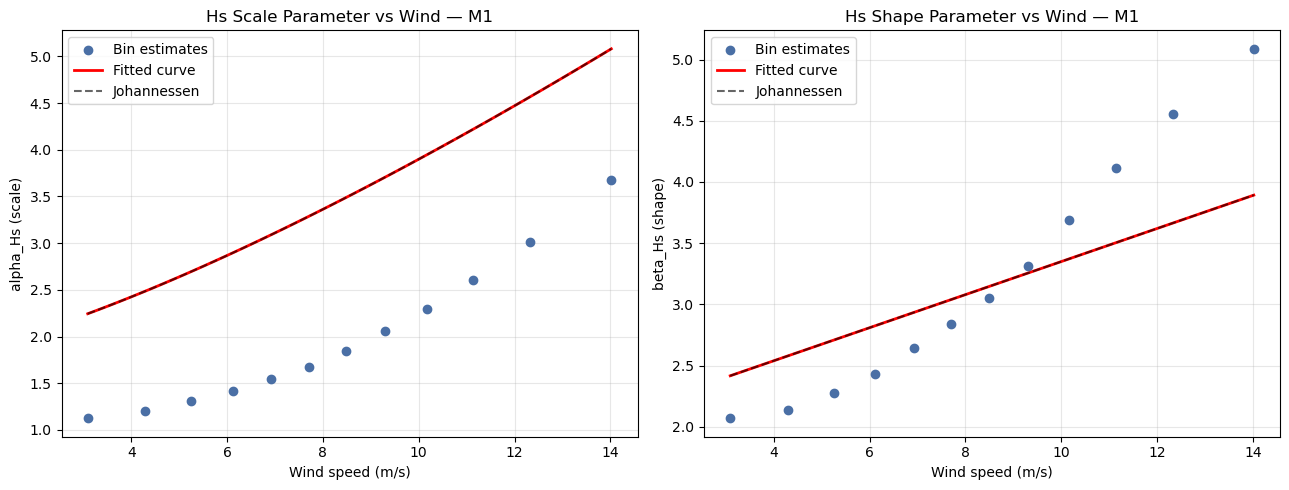


--- Tp conditional on Hs and wind ---
Conditional Tp|Hs,Wind model (Johannessen eq 6-8):
  mu_Tp  = (4.8830 + 2.6800*hs^0.5290) * (1 - 0.1900*(uw-mu_w)/mu_w)
  mu_w(hs) = 1.7640 + 3.4260*hs^0.7800
  sigma_vTp = -0.001700 + 0.2590*exp(-0.1130*hs)
  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19
  Johannessen: d1=1.764, d2=3.426, d3=0.78
  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113


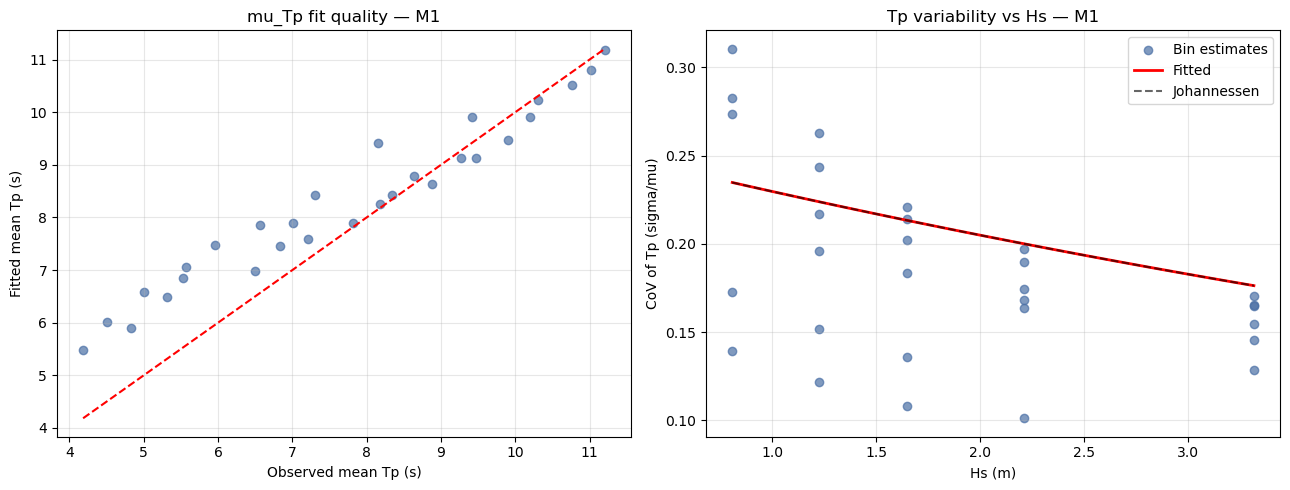


--- Generating 100-year contour ---
Contour summary:
  Max W  (10m, 1h):    29.53 m/s
  Max W  (hub, 10min): 43.75 m/s
  Max Hs:              12.47 m
  Max Tp:              24.06 s
  Valid points:        5000 / 5000


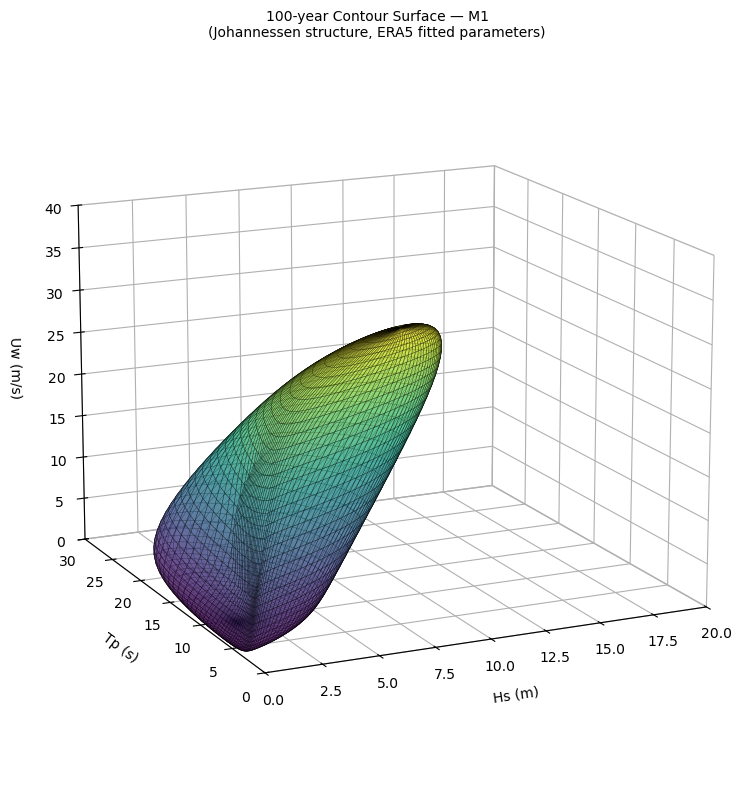


BUOY: M2

Beta (100-year, 8766 obs/yr): 4.7267

--- Wind marginal ---
Marginal Weibull for wind speed (Johannessen eq 4):
  alpha_W (scale): 9.3879
  beta_W  (shape): 2.2831
  mean from fit:   8.3162 m/s


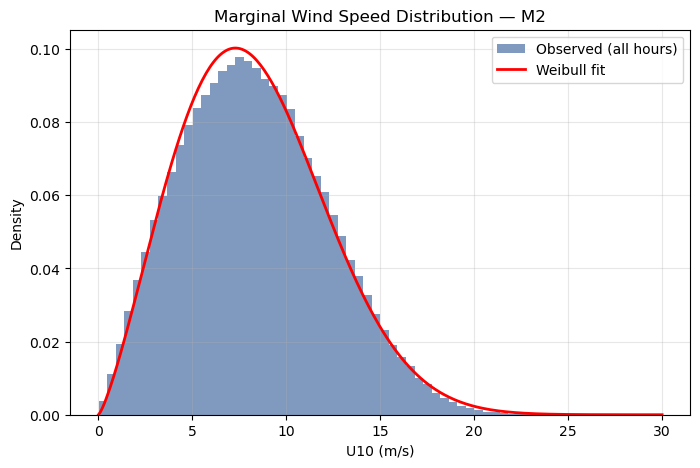


--- Hs conditional on wind ---
Conditional Hs|Wind model (Johannessen eq 5):
  alpha_Hs = 1.8000 + 0.1000 * w^1.3220
  beta_Hs  = 2.0000 + 0.1350 * w
  Johannessen reference: alpha = 1.8 + 0.100*w^1.322
  Johannessen reference: beta  = 2.0 + 0.135*w


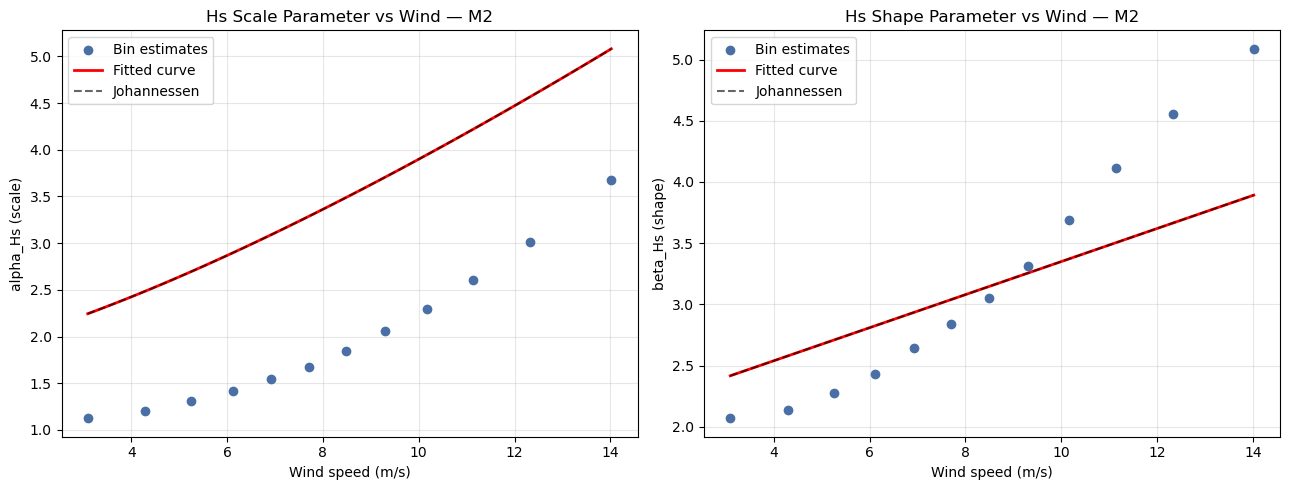


--- Tp conditional on Hs and wind ---
Conditional Tp|Hs,Wind model (Johannessen eq 6-8):
  mu_Tp  = (4.8830 + 2.6800*hs^0.5290) * (1 - 0.1900*(uw-mu_w)/mu_w)
  mu_w(hs) = 1.7640 + 3.4260*hs^0.7800
  sigma_vTp = -0.001700 + 0.2590*exp(-0.1130*hs)
  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19
  Johannessen: d1=1.764, d2=3.426, d3=0.78
  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113


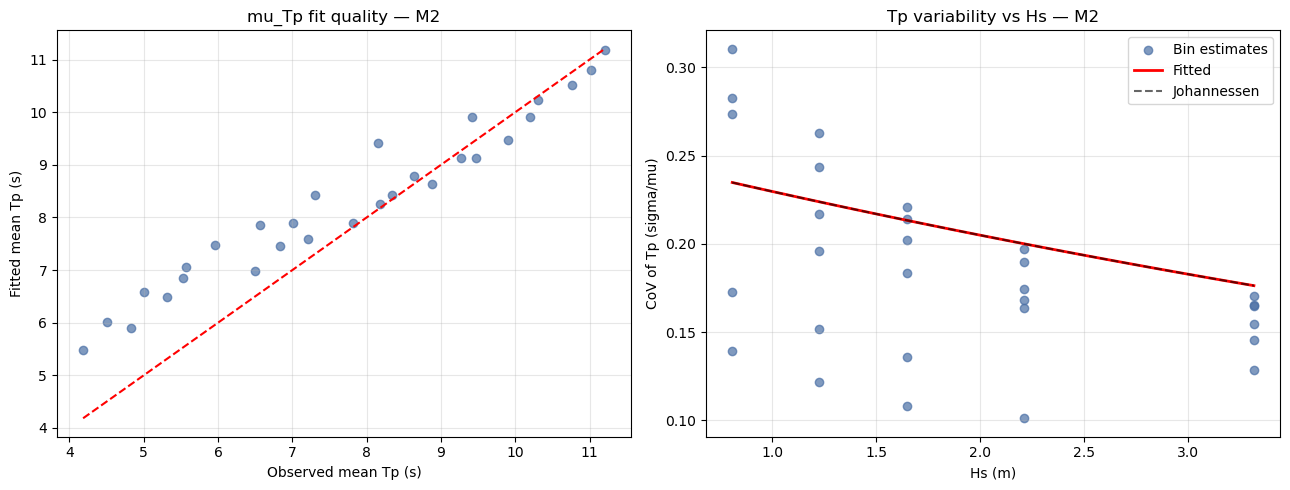


--- Generating 100-year contour ---
Contour summary:
  Max W  (10m, 1h):    29.53 m/s
  Max W  (hub, 10min): 43.75 m/s
  Max Hs:              12.47 m
  Max Tp:              24.06 s
  Valid points:        5000 / 5000


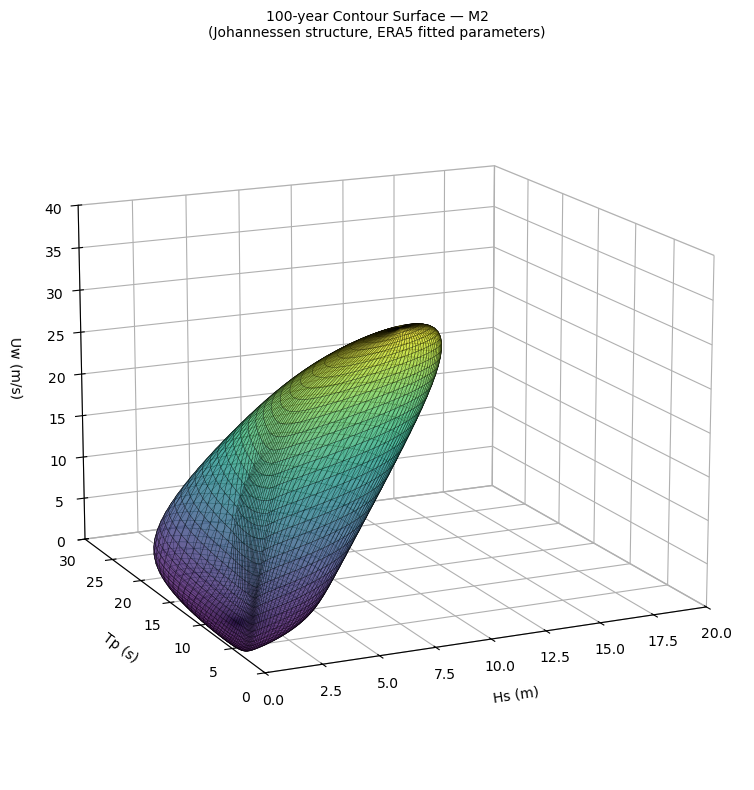


BUOY: M3

Beta (100-year, 8766 obs/yr): 4.7267

--- Wind marginal ---
Marginal Weibull for wind speed (Johannessen eq 4):
  alpha_W (scale): 9.3879
  beta_W  (shape): 2.2831
  mean from fit:   8.3162 m/s


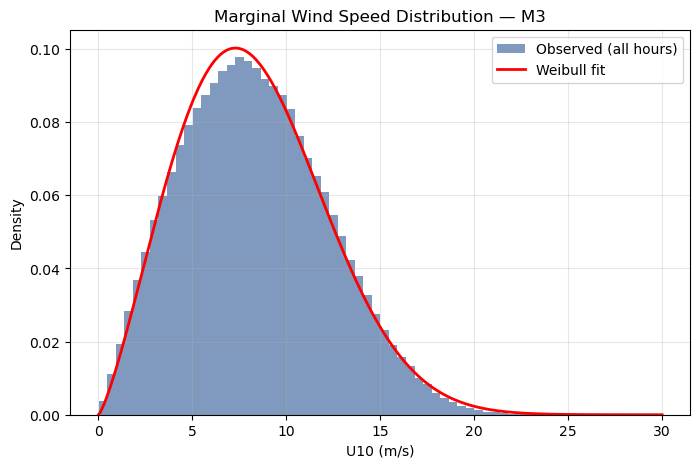


--- Hs conditional on wind ---
Conditional Hs|Wind model (Johannessen eq 5):
  alpha_Hs = 1.8000 + 0.1000 * w^1.3220
  beta_Hs  = 2.0000 + 0.1350 * w
  Johannessen reference: alpha = 1.8 + 0.100*w^1.322
  Johannessen reference: beta  = 2.0 + 0.135*w


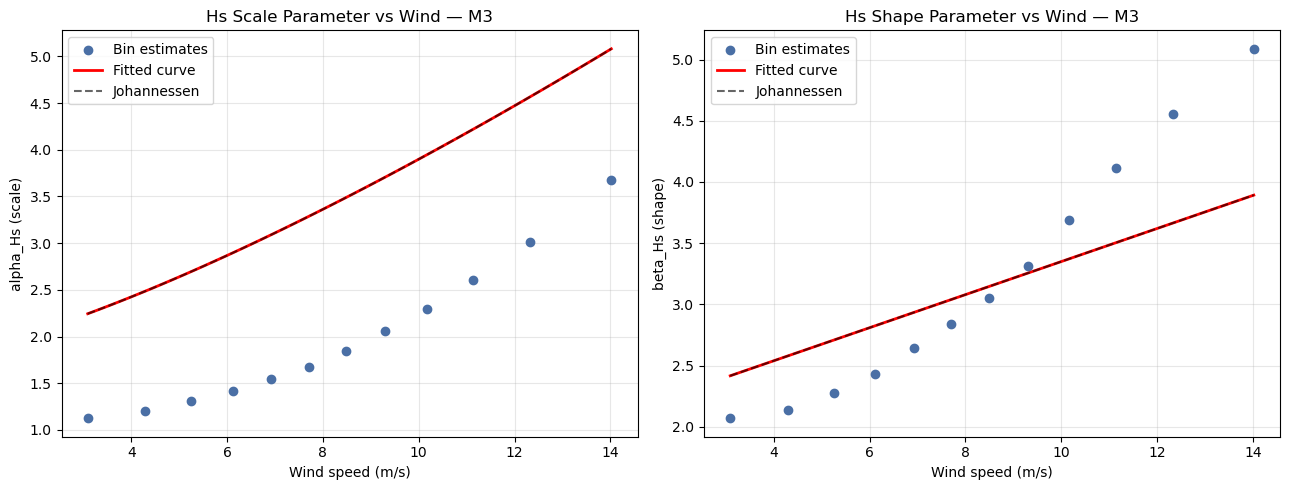


--- Tp conditional on Hs and wind ---
Conditional Tp|Hs,Wind model (Johannessen eq 6-8):
  mu_Tp  = (4.8830 + 2.6800*hs^0.5290) * (1 - 0.1900*(uw-mu_w)/mu_w)
  mu_w(hs) = 1.7640 + 3.4260*hs^0.7800
  sigma_vTp = -0.001700 + 0.2590*exp(-0.1130*hs)
  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19
  Johannessen: d1=1.764, d2=3.426, d3=0.78
  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113


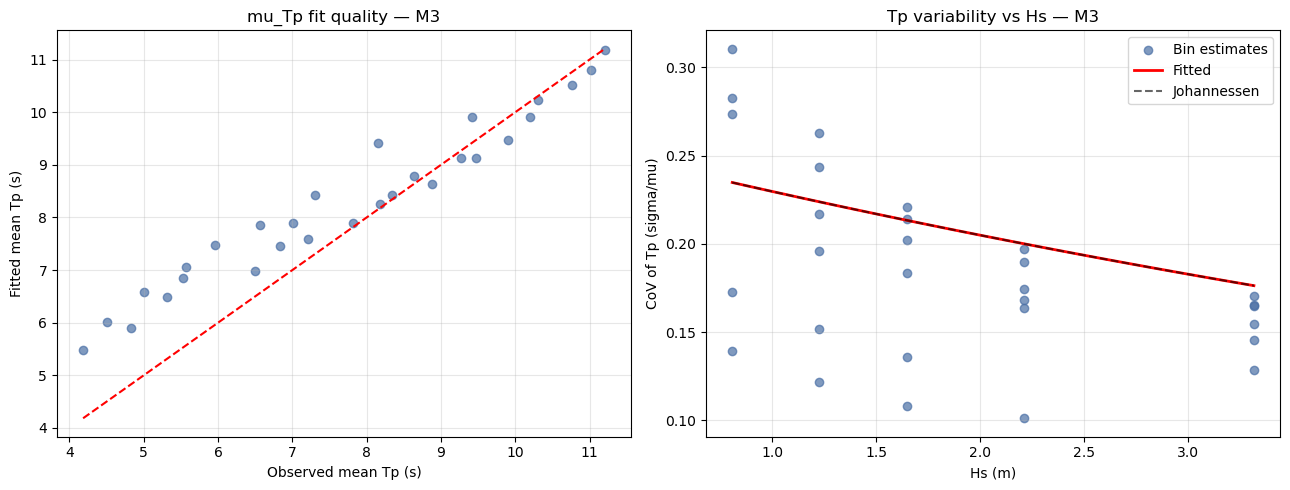


--- Generating 100-year contour ---
Contour summary:
  Max W  (10m, 1h):    29.53 m/s
  Max W  (hub, 10min): 43.75 m/s
  Max Hs:              12.47 m
  Max Tp:              24.06 s
  Valid points:        5000 / 5000


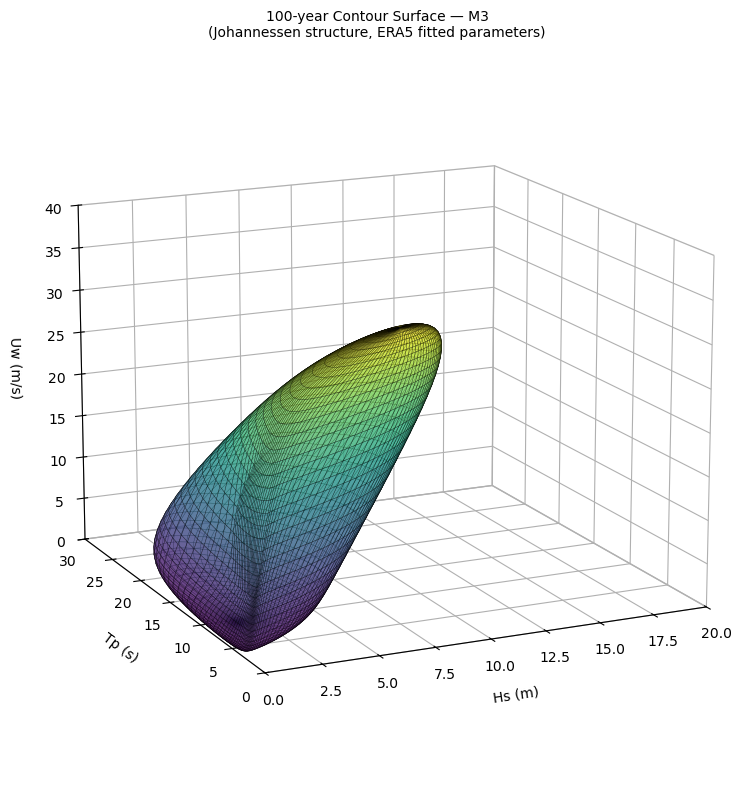


BUOY: M4

Beta (100-year, 8766 obs/yr): 4.7267

--- Wind marginal ---
Marginal Weibull for wind speed (Johannessen eq 4):
  alpha_W (scale): 9.3879
  beta_W  (shape): 2.2831
  mean from fit:   8.3162 m/s


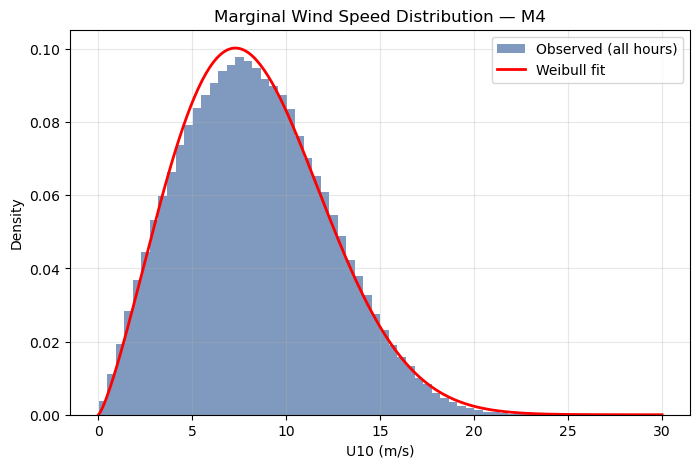


--- Hs conditional on wind ---
Conditional Hs|Wind model (Johannessen eq 5):
  alpha_Hs = 1.8000 + 0.1000 * w^1.3220
  beta_Hs  = 2.0000 + 0.1350 * w
  Johannessen reference: alpha = 1.8 + 0.100*w^1.322
  Johannessen reference: beta  = 2.0 + 0.135*w


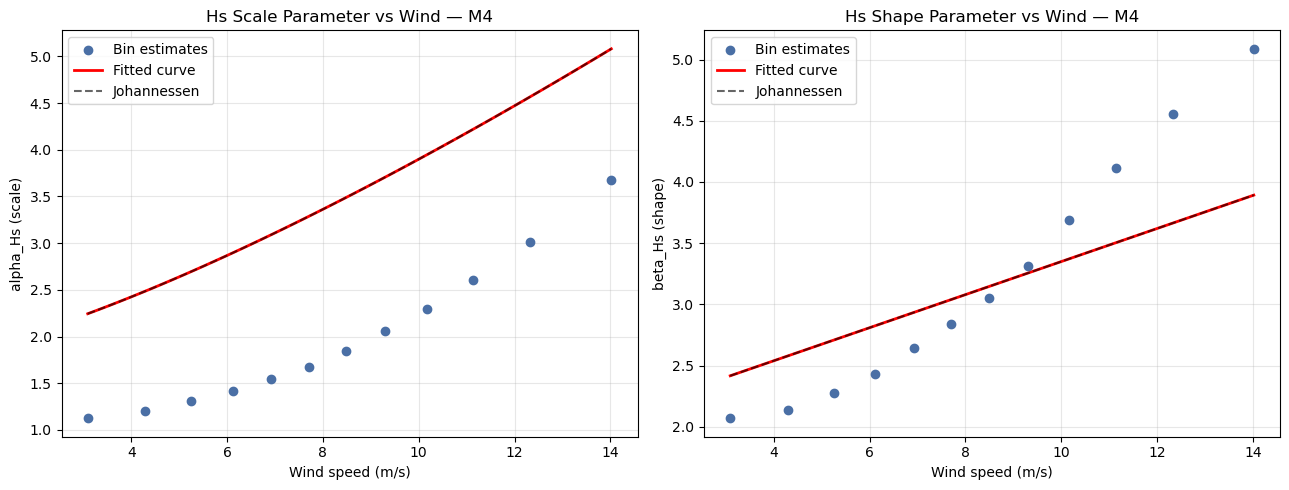


--- Tp conditional on Hs and wind ---
Conditional Tp|Hs,Wind model (Johannessen eq 6-8):
  mu_Tp  = (4.8830 + 2.6800*hs^0.5290) * (1 - 0.1900*(uw-mu_w)/mu_w)
  mu_w(hs) = 1.7640 + 3.4260*hs^0.7800
  sigma_vTp = -0.001700 + 0.2590*exp(-0.1130*hs)
  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19
  Johannessen: d1=1.764, d2=3.426, d3=0.78
  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113


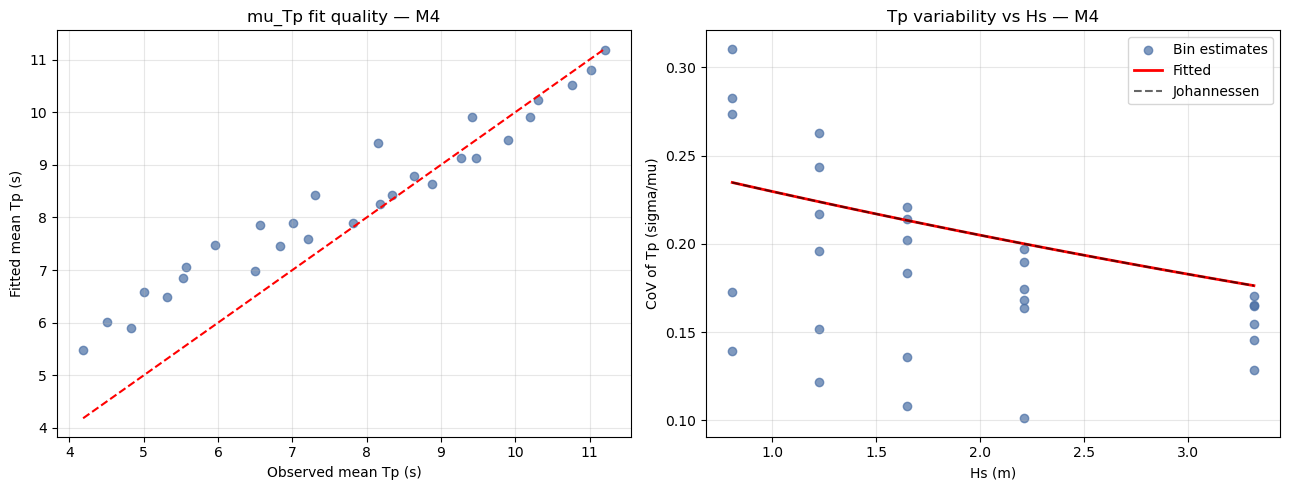


--- Generating 100-year contour ---
Contour summary:
  Max W  (10m, 1h):    29.53 m/s
  Max W  (hub, 10min): 43.75 m/s
  Max Hs:              12.47 m
  Max Tp:              24.06 s
  Valid points:        5000 / 5000


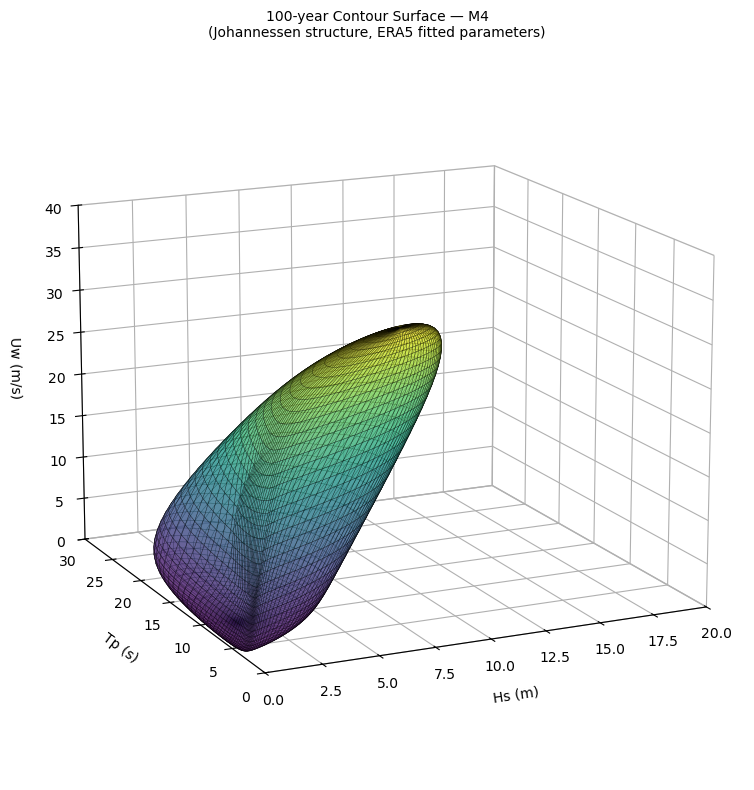


BUOY: M5

Beta (100-year, 8766 obs/yr): 4.7267

--- Wind marginal ---
Marginal Weibull for wind speed (Johannessen eq 4):
  alpha_W (scale): 9.3879
  beta_W  (shape): 2.2831
  mean from fit:   8.3162 m/s


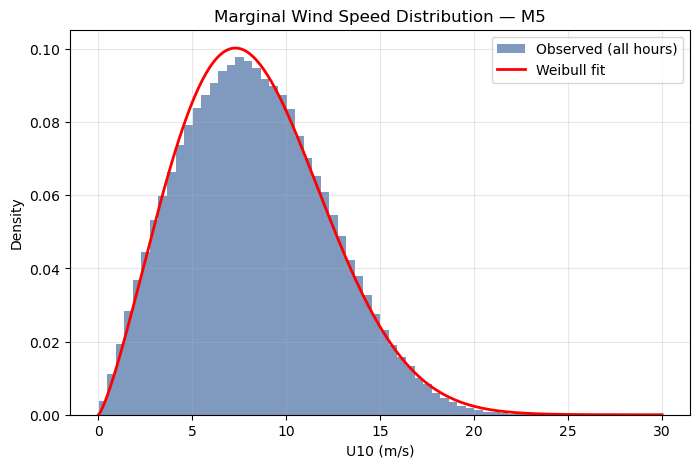


--- Hs conditional on wind ---
Conditional Hs|Wind model (Johannessen eq 5):
  alpha_Hs = 1.8000 + 0.1000 * w^1.3220
  beta_Hs  = 2.0000 + 0.1350 * w
  Johannessen reference: alpha = 1.8 + 0.100*w^1.322
  Johannessen reference: beta  = 2.0 + 0.135*w


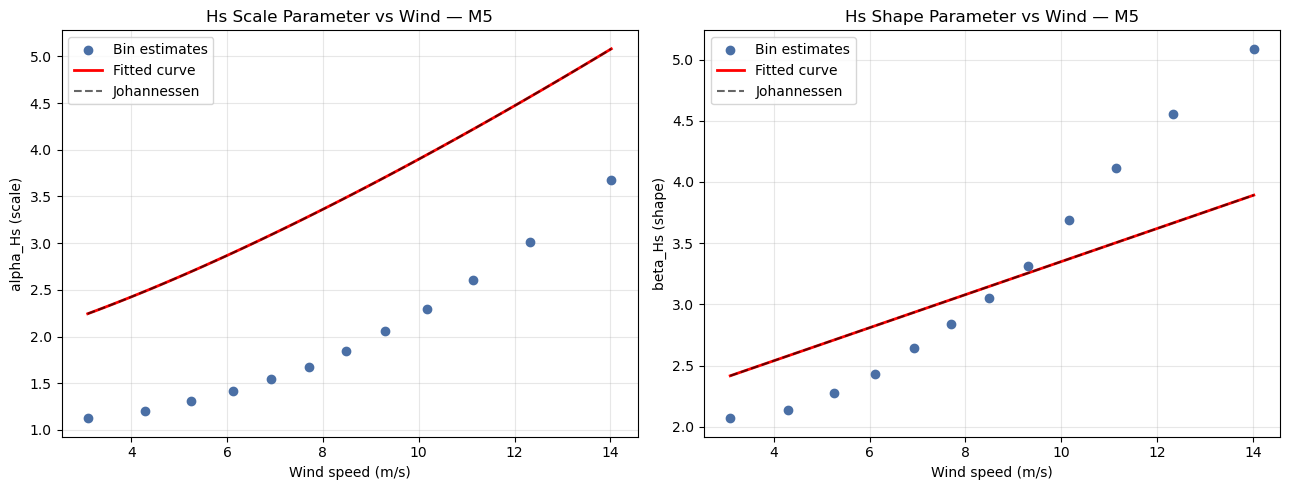


--- Tp conditional on Hs and wind ---
Conditional Tp|Hs,Wind model (Johannessen eq 6-8):
  mu_Tp  = (4.8830 + 2.6800*hs^0.5290) * (1 - 0.1900*(uw-mu_w)/mu_w)
  mu_w(hs) = 1.7640 + 3.4260*hs^0.7800
  sigma_vTp = -0.001700 + 0.2590*exp(-0.1130*hs)
  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19
  Johannessen: d1=1.764, d2=3.426, d3=0.78
  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113


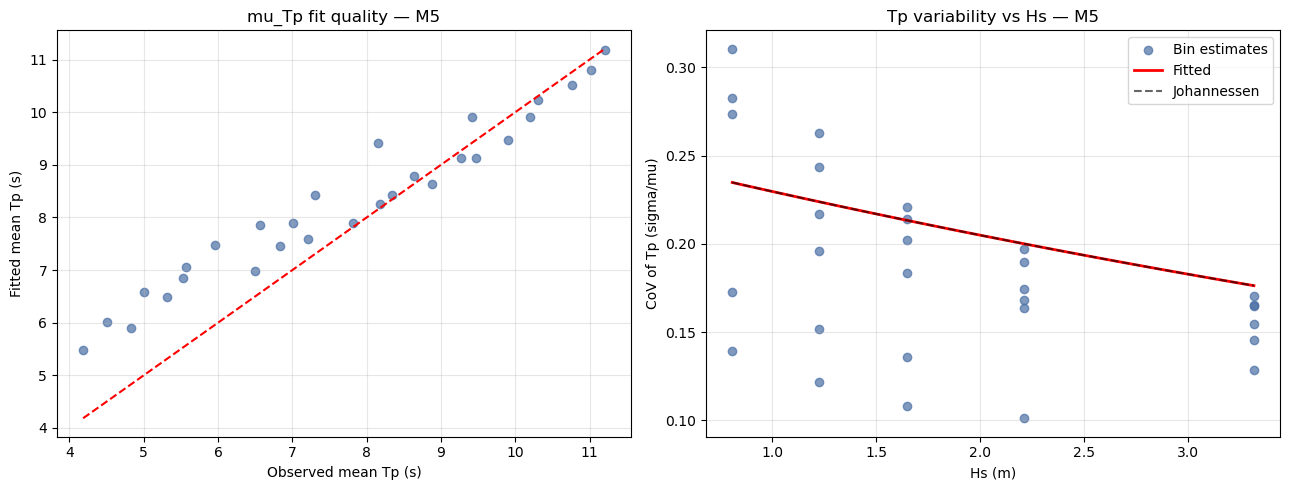


--- Generating 100-year contour ---
Contour summary:
  Max W  (10m, 1h):    29.53 m/s
  Max W  (hub, 10min): 43.75 m/s
  Max Hs:              12.47 m
  Max Tp:              24.06 s
  Valid points:        5000 / 5000


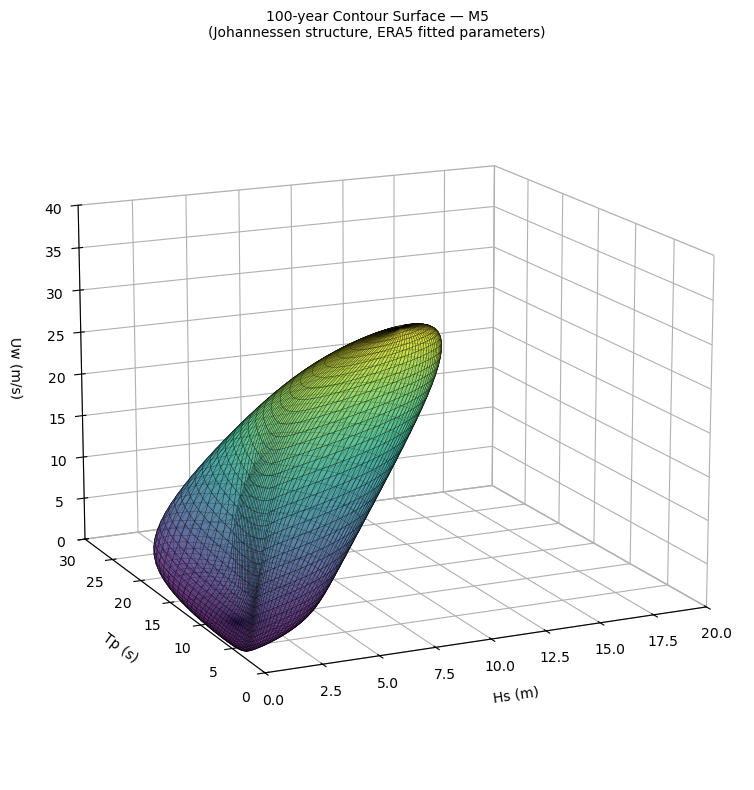


BUOY: M6

Beta (100-year, 8766 obs/yr): 4.7267

--- Wind marginal ---
Marginal Weibull for wind speed (Johannessen eq 4):
  alpha_W (scale): 9.3879
  beta_W  (shape): 2.2831
  mean from fit:   8.3162 m/s


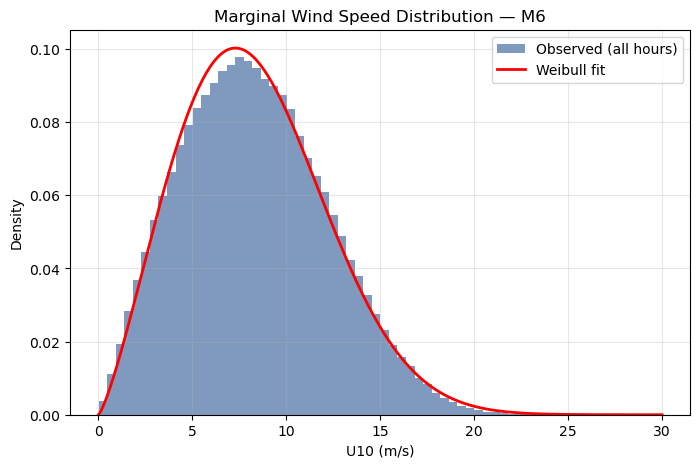


--- Hs conditional on wind ---
Conditional Hs|Wind model (Johannessen eq 5):
  alpha_Hs = 1.8000 + 0.1000 * w^1.3220
  beta_Hs  = 2.0000 + 0.1350 * w
  Johannessen reference: alpha = 1.8 + 0.100*w^1.322
  Johannessen reference: beta  = 2.0 + 0.135*w


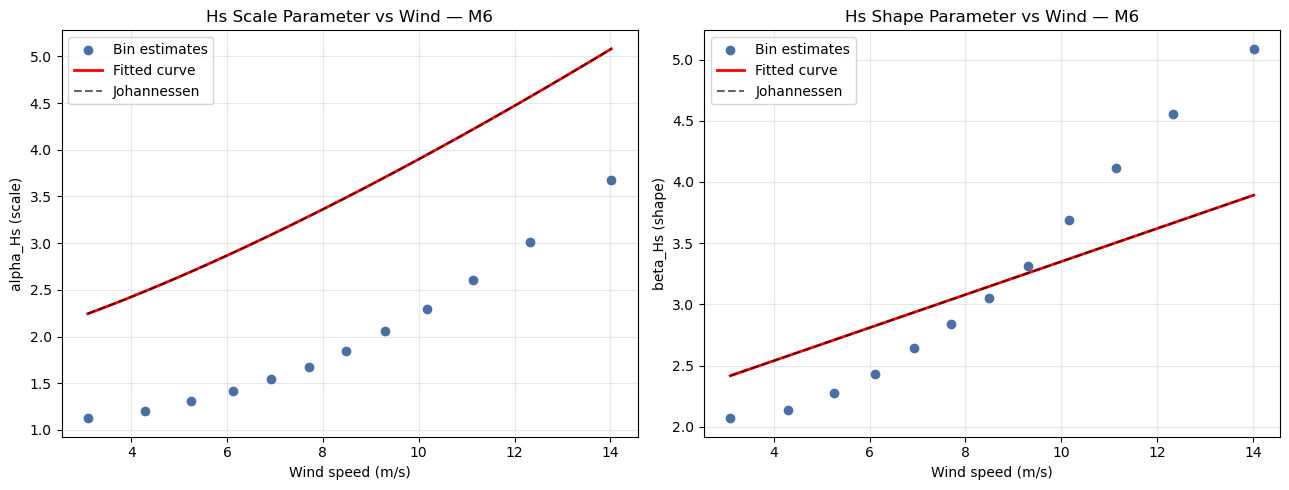


--- Tp conditional on Hs and wind ---
Conditional Tp|Hs,Wind model (Johannessen eq 6-8):
  mu_Tp  = (4.8830 + 2.6800*hs^0.5290) * (1 - 0.1900*(uw-mu_w)/mu_w)
  mu_w(hs) = 1.7640 + 3.4260*hs^0.7800
  sigma_vTp = -0.001700 + 0.2590*exp(-0.1130*hs)
  Johannessen: c1=4.883, c2=2.68, c3=0.529, c4=0.19
  Johannessen: d1=1.764, d2=3.426, d3=0.78
  Johannessen: e1=-1.7e-3, e2=0.259, e3=-0.113


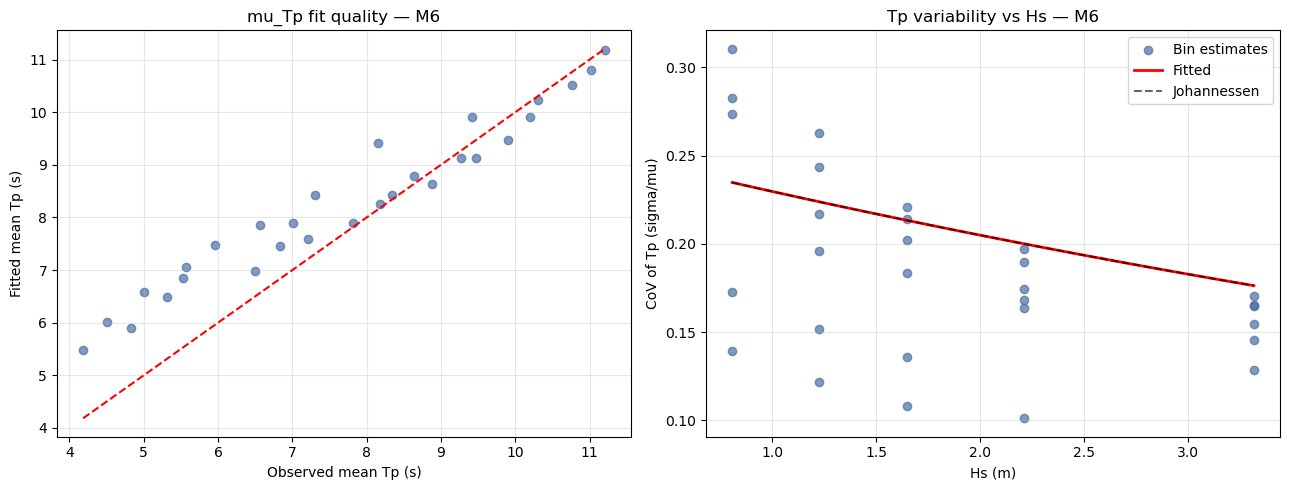


--- Generating 100-year contour ---
Contour summary:
  Max W  (10m, 1h):    29.53 m/s
  Max W  (hub, 10min): 43.75 m/s
  Max Hs:              12.47 m
  Max Tp:              24.06 s
  Valid points:        5000 / 5000


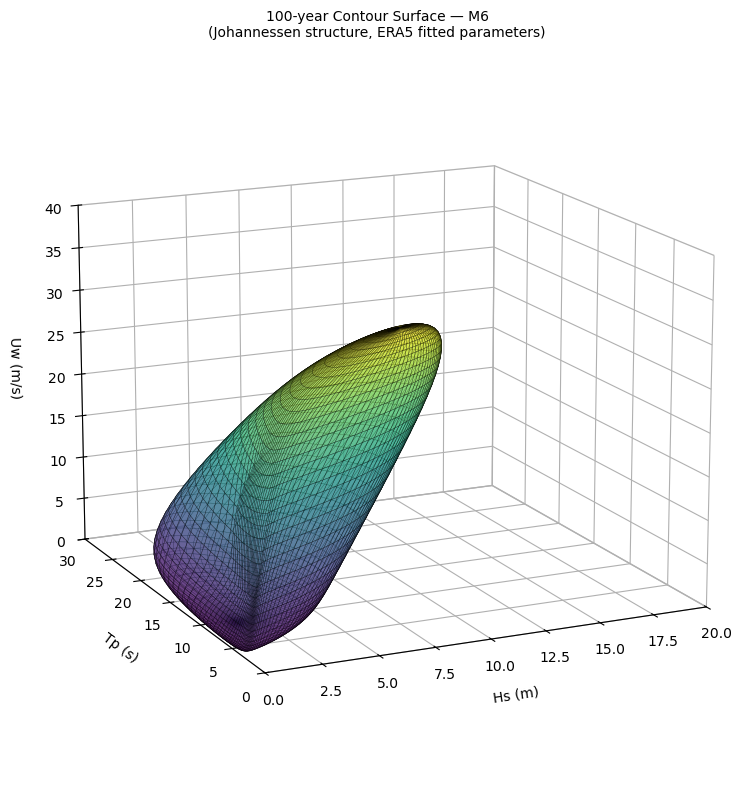


All buoys complete.


In [87]:
K1Y           = 8760    # hourly observations per year — Johannessen convention
return_period = 100     # years

fitted_params_by_buoy = {}

for buoy_name, data in location_wise_data.items():
    print(f"\n{'='*60}")
    print(f"BUOY: {buoy_name}")
    print('='*60)

    df       = data["df"]
    w10_all  = df["w10"].values
    hs_all   = df["Hs"].values
    tp_all   = df["Tp"].values

    # ── Beta (all sea states, Johannessen convention) ─────────────────
    n_years        = (df.index[-1] - df.index[0]).days / 365.25
    n_obs_per_year = len(df) / n_years
    Pf             = 1 / (return_period * n_obs_per_year)
    beta           = norm.ppf(1 - Pf)
    print(f"\nBeta ({return_period}-year, {n_obs_per_year:.0f} obs/yr): {beta:.4f}")

    # ── Step 1: Fit wind marginal ─────────────────────────────────────
    print("\n--- Wind marginal ---")
    w_shape, w_scale = fit_wind_weibull(w10_all, show_plot=True,
                                         buoy_name=buoy_name)

    # ── Step 2: Fit Hs | Wind ────────────────────────────────────────
    print("\n--- Hs conditional on wind ---")
    a1, a2, a3, b1, b2 = fit_hs_given_wind(w10_all, hs_all,
                                             show_plot=True,
                                             buoy_name=buoy_name)

    # ── Step 3: Fit Tp | Hs, Wind ────────────────────────────────────
    print("\n--- Tp conditional on Hs and wind ---")
    c1,c2,c3,c4,d1,d2,d3,e1,e2,e3 = fit_tp_given_hs_wind(
        w10_all, hs_all, tp_all,
        show_plot=True, buoy_name=buoy_name
    )

    # ── Step 4: Build transformation functions ────────────────────────
    u1_to_W, u2_to_Hs, u3_to_Tp = make_transform_functions(
        w_shape, w_scale,
        a1, a2, a3, b1, b2,
        c1, c2, c3, c4, d1, d2, d3,
        e1, e2, e3
    )

    # ── Step 5: Generate contour ──────────────────────────────────────
    print(f"\n--- Generating {return_period}-year contour ---")
    W_contour, Hs_contour, Tp_contour = generate_contour_johannessen(
        beta, u1_to_W, u2_to_Hs, u3_to_Tp,
        n_theta=50, n_phi=100
    )

    # ── Step 6: Store ─────────────────────────────────────────────────
    fitted_params_by_buoy[buoy_name] = {
        "beta": beta,
        "w_shape": w_shape, "w_scale": w_scale,
        "a1": a1, "a2": a2, "a3": a3,
        "b1": b1, "b2": b2,
        "c1": c1, "c2": c2, "c3": c3, "c4": c4,
        "d1": d1, "d2": d2, "d3": d3,
        "e1": e1, "e2": e2, "e3": e3,
        "W_contour":  W_contour,
        "Hs_contour": Hs_contour,
        "Tp_contour": Tp_contour,
    }

    # ── Step 7: 3D plot ───────────────────────────────────────────────
    W_plot  = np.ma.masked_invalid(W_contour)
    Hs_plot = np.ma.masked_invalid(Hs_contour)
    Tp_plot = np.ma.masked_invalid(Tp_contour)

    fig = plt.figure(figsize=(10, 8))
    ax  = fig.add_subplot(111, projection='3d')
    ax.plot_surface(Hs_plot, Tp_plot, W_plot,
                    cmap='viridis', alpha=0.55,
                    linewidth=0.3, edgecolor='k',
                    rstride=1, cstride=1)
    ax.set_xlabel('Hs (m)',   labelpad=10)
    ax.set_ylabel('Tp (s)',   labelpad=10)
    ax.set_zlabel('Uw (m/s)', labelpad=10)
    ax.set_xlim(0, 20); ax.set_ylim(0, 30); ax.set_zlim(0, 40)
    ax.invert_xaxis(); ax.invert_yaxis()
    for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
        pane.fill = False
        pane.set_edgecolor('lightgrey')
    ax.view_init(elev=15, azim=65)
    ax.set_title(
        f"{return_period}-year Contour Surface — {buoy_name}\n"
        f"(Johannessen structure, ERA5 fitted parameters)",
        fontsize=10
    )
    plt.tight_layout()
    plt.show()

print("\nAll buoys complete.")